In [2]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import numpy as np
import math
import pickle
from itertools import product
from tqdm.notebook import tqdm

from cx.model import *
from loss import *

In [45]:
model_name = "bee-mean-conn"
bias = -0.125
model = Model(f"data/{model_name[:3]}-cells.csv", f"data/{model_name}.npy", model_name)

#filename = f"data/tuning/{model_name}_E=0.1..10.0_I=0.1..10.0_bias={bias}..{bias}_compass=1.0..1.0"
filename = f"data/tuning/{model_name}_E=0.1778279410038923..0.31622776601683794_I=1.0..10.0_bias={bias}..{bias}_compass=1.0..1.0"

#with open(f"data/tuning/{model_name}_E=0.06309573444801933..6.309573444801933_I=0.1..10.0_bias=-0.25..-0.25_compass=1.0..1.0.pkl", "rb") as f:
with open(filename + ".params.pkl", "rb") as f:
    data = pickle.load(f)
    
parameters = list(product(data["Es"], data["Is"], data["biases"], data["compass_strengths"]))

exc.norm: 19.187450408935547, inh.norm: 61.317970275878906


In [46]:
loss = np.load(filename + "_zoom.loss.npy")

(np.int64(30), np.int64(76), np.int64(0), np.int64(0))
(np.float64(0.21171789908482727), np.float64(5.857020818056667), np.float64(-0.125), np.float64(1.0))
[1.80000000e+01 6.92483540e-01 2.19173772e-02 9.89092624e-01
 1.21869429e+00 3.35895055e-03            nan 7.09301973e-01
 1.71742461e-01 1.76397295e-02 1.74068721e-02 1.85337396e-02
 1.75281908e-02 4.28504701e-01 3.73368328e-02]


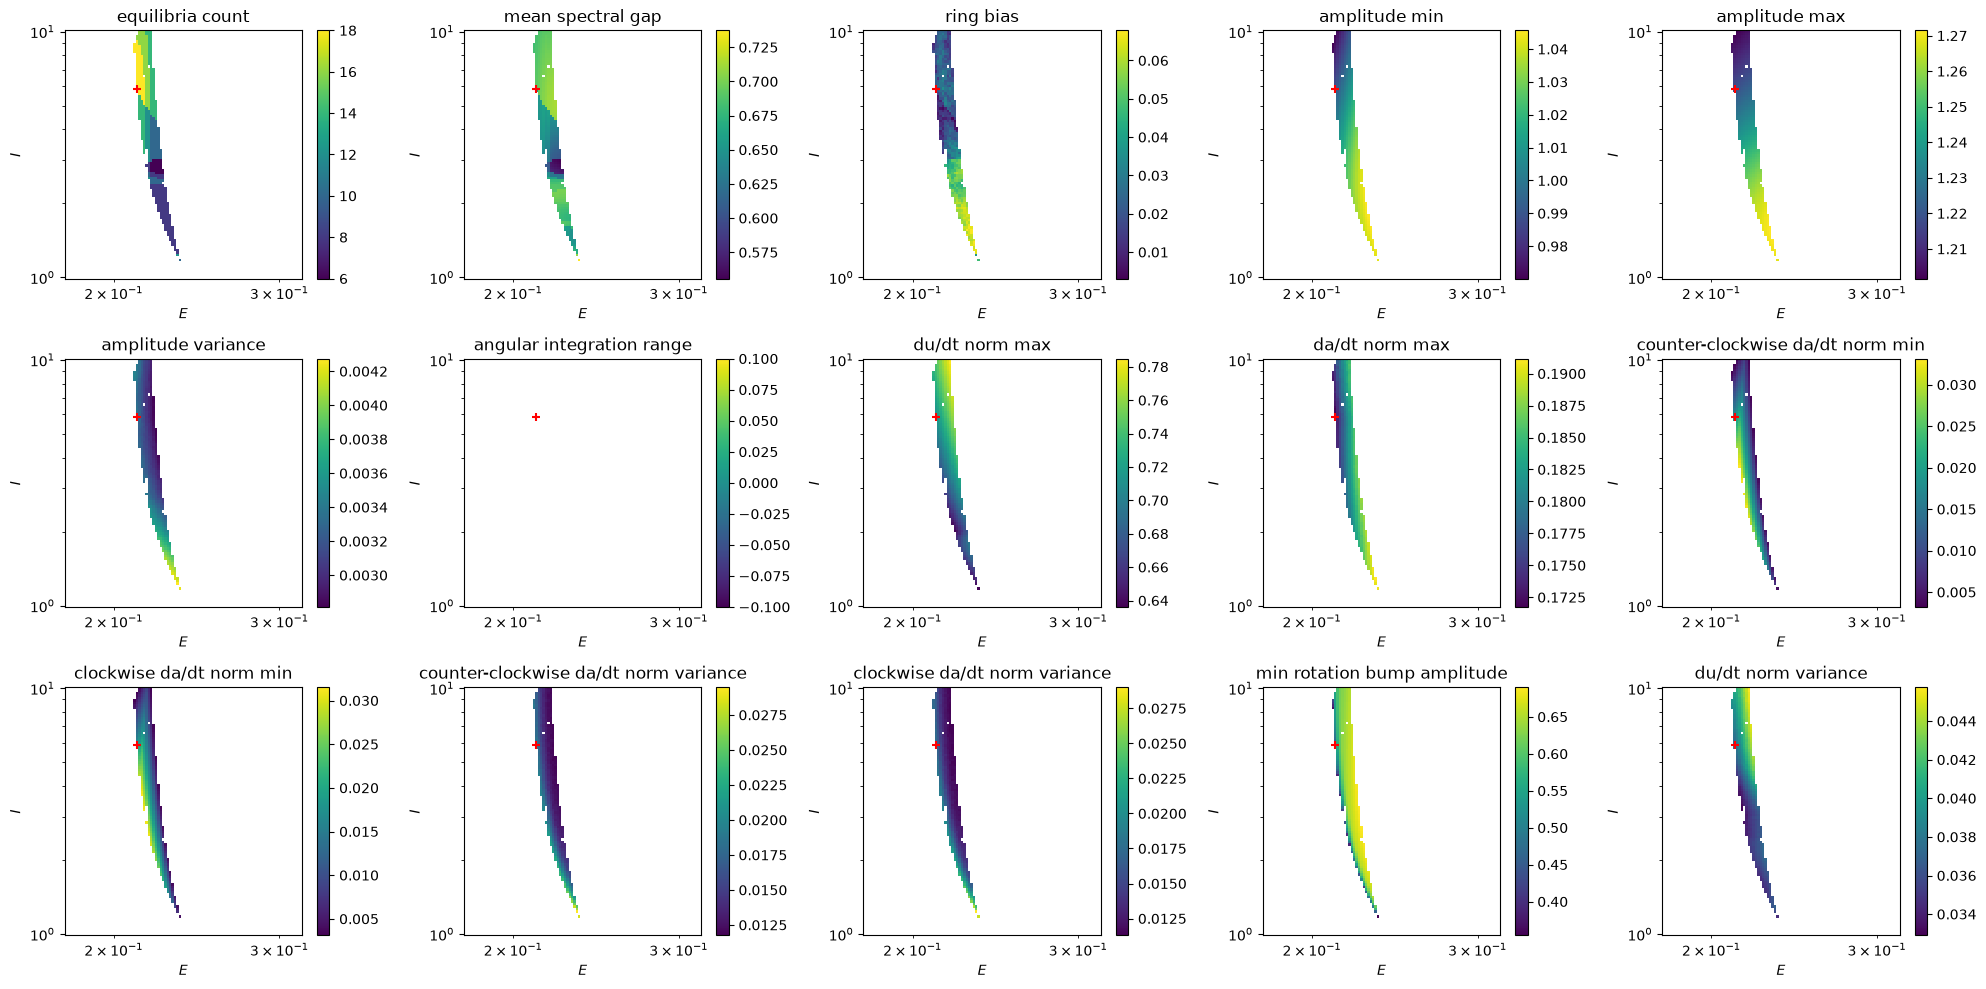

In [47]:
mask = loss[AMP_MIN,...] > 0.0
mask &= (loss[BIAS,...] < 0.1)
#mask &= ((loss[AMP_MAX,...] - loss[AMP_MIN,...]) < 0.25)

#mask &= (~np.isnan(loss[CCW_SPEED_MIN,...]))
mask &= (loss[CCW_SPEED_MIN,...] > 0.0)
mask &= (loss[CW_SPEED_MIN,...] > 0.0)
#mask = (loss[MIN_ROTATION] > -.5) #& ((loss[AMP_MAX] - loss[AMP_MIN,...]) < 0.1)
#mask = loss[MIN_ROTATION,...] > 0
#mask = loss[AMP_MIN,...] > 0.0

filtered_loss = np.nan * np.zeros_like(loss)
filtered_loss[:,mask] = loss[:,mask]

#filtered_loss = filtered_loss[:,:,:,2:,:]
#print(filtered_loss.shape)

#crosshair = (10, 10, 2, 1)
#crosshair = np.unravel_index(np.nanargmin(filtered_loss[AMP_MAX,...] - filtered_loss[AMP_MIN,...]), loss.shape[1:])
#crosshair = np.unravel_index(np.nanargmax(filtered_loss[MIN_ROTATION,...]), loss.shape[1:])
#crosshair = np.unravel_index(np.nanargmin(filtered_loss[CW_SPEED_VAR,...]), loss.shape[1:])
#crosshair = np.unravel_index(np.nanargmin(filtered_loss[CCW_SPEED_VAR,...] + filtered_loss[CW_SPEED_VAR,...]), loss.shape[1:])
#crosshair = np.unravel_index(np.nanargmax(filtered_loss[NUM_EQUILIBRIA,...]), loss.shape[1:])

# Number of equilibria:
#crosshair = np.unravel_index(np.nanargmax(filtered_loss[NUM_EQUILIBRIA,...]), loss.shape[1:])

_, Is, _, _ = np.meshgrid(data["Es"], data["Is"], data["biases"], data["compass_strengths"])

# Slowness
crosshair = np.unravel_index(np.nanargmin(filtered_loss[ANGULAR_SPEED_MAX,...]), loss.shape[1:])
#crosshair = np.unravel_index(np.nanargmin(filtered_loss[ANGULAR_SPEED_MAX,...] - (filtered_loss[CW_SPEED_MIN,...] + filtered_loss[CCW_SPEED_MIN]) + 0.5 * Is), loss.shape[1:])
#crosshair = np.unravel_index(np.nanargmin(filtered_loss[ANGULAR_SPEED_MAX,...] - (filtered_loss[CW_SPEED_MIN,...] + filtered_loss[CCW_SPEED_MIN])), loss.shape[1:])
#crosshair = np.unravel_index(np.nanargmin(filtered_loss[ANGULAR_SPEED_MAX,...] - 0.5 * Is), loss.shape[1:])
#crosshair = np.unravel_index(np.nanargmin(filtered_loss[ANGULAR_SPEED_MAX,...] - 0.5 * Is), loss.shape[1:])
#crosshair = np.unravel_index(np.nanargmin(filtered_loss[ANGULAR_SPEED_MAX,...] - 0.1 * filtered_loss[MEAN_SPECTRAL_GAP,...]), loss.shape[1:])
#crosshair = np.unravel_index(np.nanargmin(filtered_loss[ANGULAR_SPEED_MAX,...] - 0.1 * filtered_loss[AMP_MIN,...]), loss.shape[1:])


#crosshair = np.unravel_index(np.nanargmin(filtered_loss[BIAS,...]), loss.shape[1:])

print(crosshair)
slice = filtered_loss[:,:,:,*crosshair[-2:]]

index = np.ravel_multi_index(crosshair, loss[0,...].shape)
params = parameters[index]

print(params)
print(loss[:,*crosshair])

fig, axes = plt.subplots(3, 5, figsize=(20, 10))
axes = axes.flatten()

for ax in axes:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("$E$")
    ax.set_ylabel("$I$")

X, Y = np.meshgrid(data["Es"], data["Is"])

axes[NUM_EQUILIBRIA].set_title("equilibria count")
c = axes[NUM_EQUILIBRIA].pcolormesh(X, Y, slice[NUM_EQUILIBRIA,...].T, rasterized=True, shading="nearest")
plt.colorbar(c)

axes[MEAN_SPECTRAL_GAP].set_title("mean spectral gap")
c = axes[MEAN_SPECTRAL_GAP].pcolormesh(X, Y, slice[MEAN_SPECTRAL_GAP,...].T, rasterized=True, shading="nearest")
plt.colorbar(c)

axes[BIAS].set_title("ring bias")
c = axes[BIAS].pcolormesh(X, Y, slice[BIAS,...].T, rasterized=True, shading="nearest")
plt.colorbar(c)

axes[AMP_MIN].set_title("amplitude min")
c = axes[AMP_MIN].pcolormesh(X, Y, slice[AMP_MIN,...].T, rasterized=True, shading="nearest")
plt.colorbar(c)

axes[AMP_MAX].set_title("amplitude max")
c = axes[AMP_MAX].pcolormesh(X, Y, slice[AMP_MAX,...].T, rasterized=True, shading="nearest")
plt.colorbar(c)

axes[AMP_VAR].set_title("amplitude variance")
c = axes[AMP_VAR].pcolormesh(X, Y, slice[AMP_VAR,...].T, rasterized=True, shading="nearest")
plt.colorbar(c)

axes[INTEGRATION_RANGE].set_title("angular integration range")
c = axes[INTEGRATION_RANGE].pcolormesh(X, Y, slice[INTEGRATION_RANGE,...].T, rasterized=True, shading="nearest")
plt.colorbar(c)

axes[CCW_SPEED_VAR].set_title("counter-clockwise da/dt norm variance")
c = axes[CCW_SPEED_VAR].pcolormesh(X, Y, slice[CCW_SPEED_VAR,...].T, rasterized=True, shading="nearest")
plt.colorbar(c)

axes[CW_SPEED_VAR].set_title("clockwise da/dt norm variance")
c = axes[CW_SPEED_VAR].pcolormesh(X, Y, slice[CW_SPEED_VAR,...].T, rasterized=True, shading="nearest")
plt.colorbar(c)

axes[CCW_SPEED_MIN].set_title("counter-clockwise da/dt norm min")
c = axes[CCW_SPEED_MIN].pcolormesh(X, Y, slice[CCW_SPEED_MIN,...].T, rasterized=True, shading="nearest")
plt.colorbar(c)

axes[CW_SPEED_MIN].set_title("clockwise da/dt norm min")
c = axes[CW_SPEED_MIN].pcolormesh(X, Y, slice[CW_SPEED_MIN,...].T, rasterized=True, shading="nearest")
plt.colorbar(c)

axes[MIN_ROTATION_AMP].set_title("min rotation bump amplitude")
c = axes[MIN_ROTATION_AMP].pcolormesh(X, Y, slice[MIN_ROTATION_AMP,...].T, rasterized=True, shading="nearest")
plt.colorbar(c)

axes[SPEED_MAX].set_title("du/dt norm max")
c = axes[SPEED_MAX].pcolormesh(X, Y, slice[SPEED_MAX,...].T, rasterized=True, shading="nearest")
plt.colorbar(c)

axes[ANGULAR_SPEED_MAX].set_title("da/dt norm max")
c = axes[ANGULAR_SPEED_MAX].pcolormesh(X, Y, slice[ANGULAR_SPEED_MAX,...].T, rasterized=True, shading="nearest")
plt.colorbar(c)

axes[SPEED_VAR].set_title("du/dt norm variance")
c = axes[SPEED_VAR].pcolormesh(X, Y, slice[SPEED_VAR,...].T, rasterized=True, shading="nearest")
plt.colorbar(c)

for ax in axes:
    ax.scatter(data["Es"][crosshair[0]], data["Is"][crosshair[1]], marker="+", c="red")

plt.tight_layout()
plt.savefig(f"results/{model.name}-loss.pdf")
plt.show()

3076 (np.float64(0.21171789908482727), np.float64(5.857020818056667), np.float64(-0.125), np.float64(1.0))
reached stable equilibrium (0.09868829373513983 < 0.1) after 684 iterations
reached stable equilibrium (0.09868733096095242 < 0.1) after 684 iterations
reached stable equilibrium (0.09989799265329888 < 0.1) after 422 iterations
reached stable equilibrium (0.09849639131157983 < 0.1) after 556 iterations
reached stable equilibrium (0.09939801795994023 < 0.1) after 338 iterations
reached stable equilibrium (0.09924559057406562 < 0.1) after 449 iterations
reached stable equilibrium (0.09956435312725659 < 0.1) after 500 iterations
reached stable equilibrium (0.09980123831502598 < 0.1) after 608 iterations
reached stable equilibrium (0.09805014095725512 < 0.1) after 234 iterations
reached stable equilibrium (0.0994222006899706 < 0.1) after 278 iterations
reached stable equilibrium (0.09806773035851882 < 0.1) after 234 iterations
reached stable equilibrium (0.09949929312292556 < 0.1) aft

[]

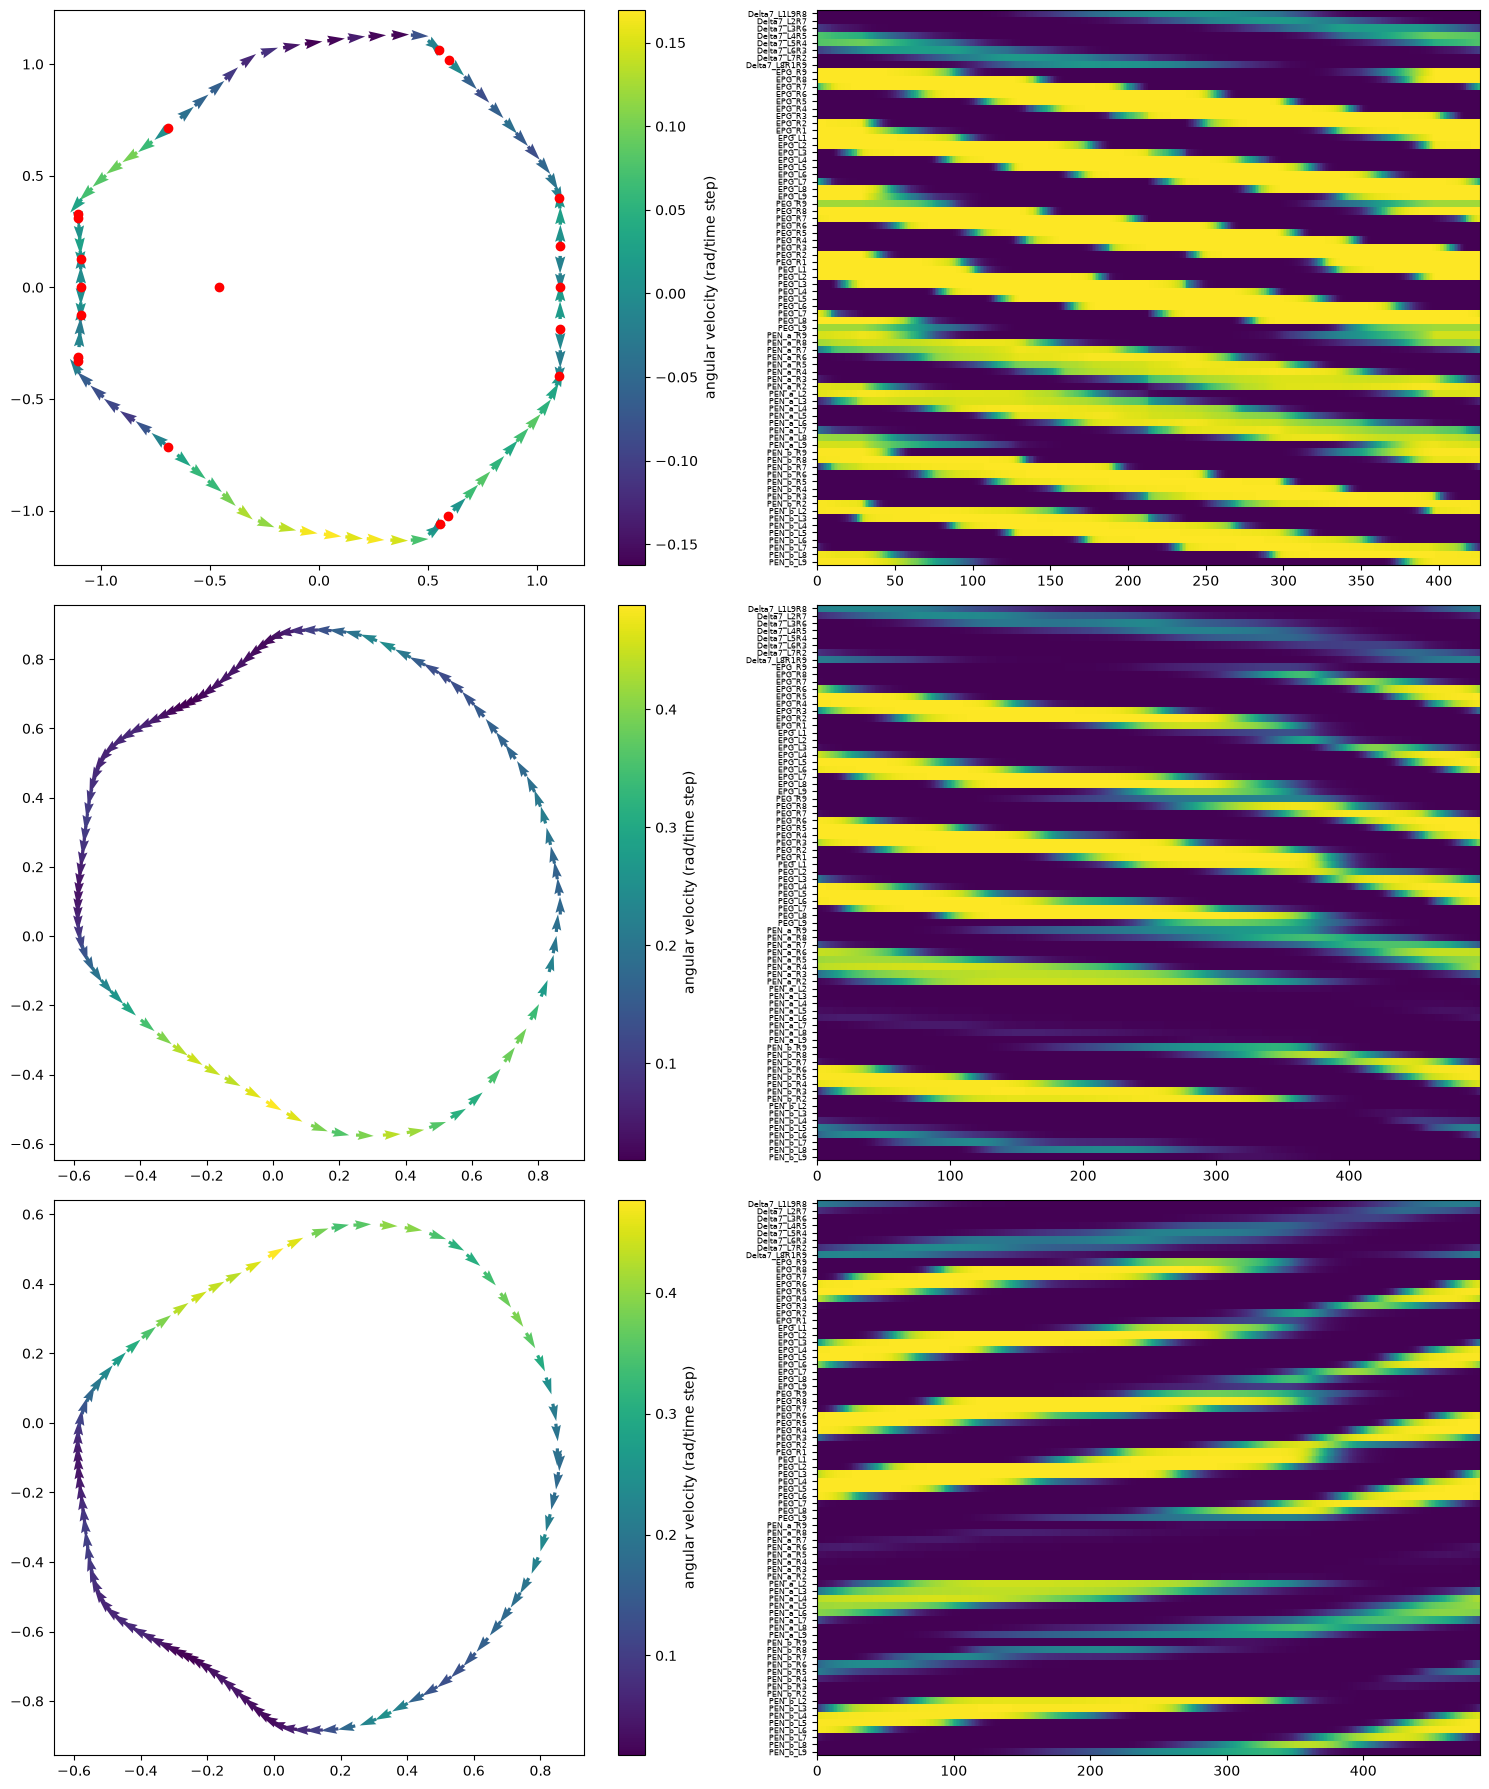

In [48]:
#index = 3351
index = np.ravel_multi_index(crosshair, loss[0,...].shape)
params = parameters[index]
#params = (np.float64(0.29286445646252374), np.float64(0.9326033468832199), -0.25, np.float64(1.0)) #parameters[index]
#index = parameters.index(params)
print(index, params)
m = model.tune(params)

cix = None
equilibria = find_equilibria(m, n_theta=50, n_r=20, threshold=0.01, dt=0.1)
equilibrium_pva = m.decode(equilibria, cix)
ring, _ = trace_ring(m, equilibria, start_offset=0.01, trace_step=0.1, dt=0.1, verbose=True)
ring_pva = m.decode(ring, cix)
indices = np.argsort(np.angle(ring_pva))
ring = ring[:,indices]
ring_pva = ring_pva[indices]

dudt_drift = m.dudt(ring, m.compass_current(np.zeros(ring.shape[1]), 0.0))
dadt = m.dangledt(ring, dudt_drift)
ring_speed = np.linalg.norm(dudt_drift, axis=0)
dudt_drift /= ring_speed
drift_pva = m.decode(ring + dudt_drift * 0.01, cix) - ring_pva
drift_pva /= np.abs(drift_pva)

fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(15, 18))
#c = ax1.scatter(np.real(ring_pva), np.imag(ring_pva), c=ring_speed)
nth = 5
c = ax1.quiver(np.real(ring_pva[::nth]), np.imag(ring_pva[::nth]), np.real(drift_pva[::nth]), np.imag(drift_pva[::nth]), dadt[::nth], scale=30) #dadt[::nth])
plt.colorbar(c, label="angular velocity (rad/time step)")

ax1.scatter(np.real(equilibrium_pva), np.imag(equilibrium_pva), c='r', label='Equilibria')

ax2.imshow(ring, rasterized=True, interpolation="nearest") #m.total_activity(ring))
ax2.set_aspect("auto")
ax2.set_yticks(np.arange(len(m.cells)), labels=m.cell_names(), fontsize=6)

# Counter-clockwise rotation cycle:
cycle, is_cycle = trace_cycle(m, equilibria, rotation=CCW_ROTATION, dt=0.1, max_steps=10000)
cycle_pva = m.decode(cycle, cix)
cycle_dudt = m.dudt(cycle, m.compass_current(np.zeros(cycle.shape[1]), 0.0) + m.rotation_current(CCW_ROTATION*np.ones(cycle.shape[1])))
cycle_dudt_pva = m.decode(cycle + cycle_dudt * 0.01, cix) - cycle_pva
cycle_dudt_pva /= np.abs(cycle_dudt_pva)
dadt = m.dangledt(cycle, cycle_dudt)
c = ax3.quiver(np.real(cycle_pva[::nth]), np.imag(cycle_pva[::nth]), np.real(cycle_dudt_pva[::nth]), np.imag(cycle_dudt_pva[::nth]), dadt[::nth], scale=30) #dadt[::nth])
ax4.imshow(cycle, rasterized=True, interpolation="nearest") #m.total_activity(ring))
ax4.set_aspect("auto")
ax4.set_yticks(np.arange(len(m.cells)), labels=m.cell_names(), fontsize=6)
plt.colorbar(c, label="angular velocity (rad/time step)")

# Clockwise rotation cycle:
cycle, is_cycle = trace_cycle(m, equilibria, rotation=CW_ROTATION, dt=0.1, max_steps=10000)
cycle_pva = m.decode(cycle, cix)
cycle_dudt = m.dudt(cycle, m.compass_current(np.zeros(cycle.shape[1]), 0.0) + m.rotation_current(CW_ROTATION*np.ones(cycle.shape[1])))
cycle_dudt_pva = m.decode(cycle + cycle_dudt * 0.01, cix) - cycle_pva
cycle_dudt_pva /= np.abs(cycle_dudt_pva)
dadt = m.dangledt(cycle, cycle_dudt)
c = ax5.quiver(np.real(cycle_pva[::nth]), np.imag(cycle_pva[::nth]), np.real(cycle_dudt_pva[::nth]), np.imag(cycle_dudt_pva[::nth]), -dadt[::nth], scale=30) #dadt[::nth])
ax6.imshow(cycle, rasterized=True, interpolation="nearest") #m.total_activity(ring))
ax6.set_aspect("auto")
ax6.set_yticks(np.arange(len(m.cells)), labels=m.cell_names(), fontsize=6)
plt.colorbar(c, label="angular velocity (rad/time step)")

plt.tight_layout()
plt.plot()